# 1. Project Overview & Configuration

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import VotingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
from catboost import CatBoostRegressor
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings('ignore')

file_path = 'data/raw/StudentPerformanceFactors.csv'
if not os.path.exists(file_path):
    file_path = '../data/raw/StudentPerformanceFactors.csv'
if not os.path.exists(file_path):
    file_path = 'StudentPerformanceFactors.csv'

# 1. Load Data
try:
    df = pd.read_csv(file_path)
    print(f"✅ Loaded successfully from: {file_path}")
    print(f"Dataset Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print("No dataset found")

✅ Loaded successfully from: ../data/raw/StudentPerformanceFactors.csv
Dataset Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# 2. Data Processing layer


In [15]:
print("Starting Data Preprocessing for Regression...")

# 1. Điền khuyết dữ liệu bằng giá trị Mode
missing_cols = ['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']
for col in missing_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 2. Ordinal Encoding thông minh (Giữ nguyên thứ bậc)
mapping_dict = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'School_Type': {'Public': 0, 'Private': 1},
    'Peer_Influence': {'Negative': 0, 'Neutral': 1, 'Positive': 2},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Gender': {'Male': 0, 'Female': 1}
}

for col, mapping in mapping_dict.items():
    df[col] = df[col].map(mapping)

# 3. Chia tập X, y
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale dữ liệu (Chỉ scale biến liên tục)
numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Data Preprocessing Complete!")

Starting Data Preprocessing for Regression...
Data Preprocessing Complete!


# 3.Trainning model

In [16]:
print("Training Ensemble Regression Model (The Fantastic Four)...")

# 1. Khởi tạo 4 mô hình cơ sở
rf = RandomForestRegressor(n_estimators=100, random_state=42)
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
cat = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, random_seed=42, verbose=0, allow_writing_files=False)
ridge = Ridge(alpha=1.0, random_state=42)

# 2. Gộp vào VotingRegressor
ensemble_model = VotingRegressor(
    estimators=[('rf', rf), ('xgb', xgb_model), ('cat', cat), ('ridge', ridge)]
)

# 3. Huấn luyện
ensemble_model.fit(X_train_scaled, y_train)
y_pred = ensemble_model.predict(X_test_scaled)
print("Model Training Complete!")

Training Ensemble Regression Model (The Fantastic Four)...
Model Training Complete!


# 4.XAI layer (SHAP & LIME)

 ENSEMBLE REGRESSION RESULTS 
MAE (Mean Absolute Error): 0.65 points
RMSE (Root Mean Squared Error): 1.88 points
R2 Score: 0.7500


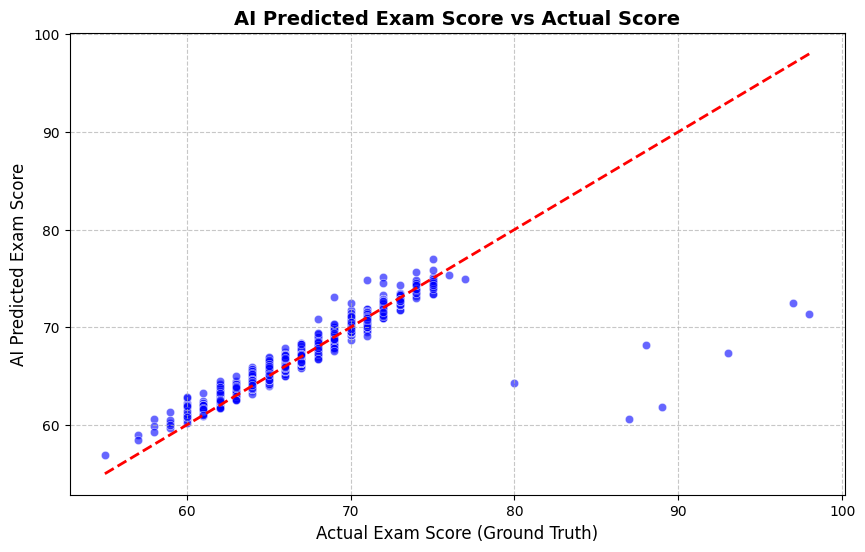

In [17]:
# 1. Tính toán các chỉ số sai số
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*40)
print(" ENSEMBLE REGRESSION RESULTS ")
print("="*40)
print(f"MAE (Mean Absolute Error): {mae:.2f} points")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} points")
print(f"R2 Score: {r2:.4f}")
print("="*40)

# 2. Vẽ biểu đồ phân tán (Actual vs Predicted)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Đường chéo chuẩn mực
plt.title("AI Predicted Exam Score vs Actual Score", fontsize=14, fontweight='bold')
plt.xlabel("Actual Exam Score (Ground Truth)", fontsize=12)
plt.ylabel("AI Predicted Exam Score", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Analyzing Student Index: 0
Predicted Score: 64.5 | Actual: 65.0


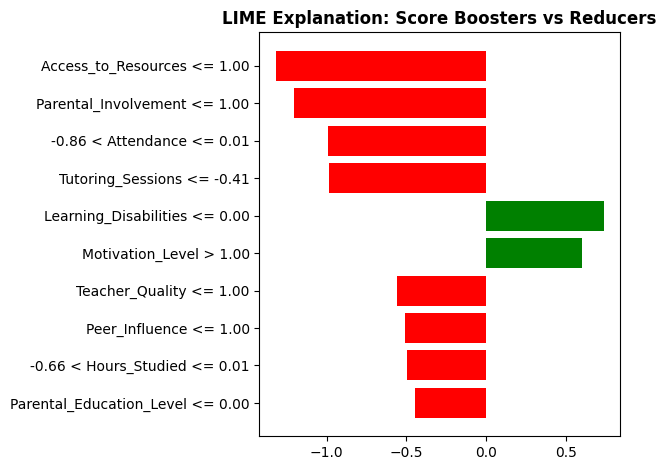


--- BẢNG CHI TIẾT TÁC ĐỘNG (ĐIỂM SỐ) ---
Access_to_Resources <= 1.00: TRỪ 1.32 điểm
Parental_Involvement <= 1.00: TRỪ 1.21 điểm
-0.86 < Attendance <= 0.01: TRỪ 0.99 điểm
Tutoring_Sessions <= -0.41: TRỪ 0.98 điểm
Learning_Disabilities <= 0.00: CỘNG 0.74 điểm
Motivation_Level > 1.00: CỘNG 0.60 điểm
Teacher_Quality <= 1.00: TRỪ 0.56 điểm
Peer_Influence <= 1.00: TRỪ 0.51 điểm
-0.66 < Hours_Studied <= 0.01: TRỪ 0.50 điểm
Parental_Education_Level <= 0.00: TRỪ 0.44 điểm


In [18]:
# 1. Tìm một sinh viên bị dự đoán dưới 65 điểm để phân tích
low_score_indices = [i for i, pred in enumerate(y_pred) if pred < 65]
sample_idx = low_score_indices[0] if len(low_score_indices) > 0 else 0

student_data = X_test_scaled.iloc[sample_idx]
predicted_score = float(y_pred[sample_idx])
actual_score = float(y_test.iloc[sample_idx])

print(f"Analyzing Student Index: {sample_idx}")
print(f"Predicted Score: {predicted_score:.1f} | Actual: {actual_score:.1f}")

# 2. Cấu hình LIME cho Hồi quy
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=feature_names,
    mode='regression', # Chế độ Regression
    random_state=42
)

# Hàm Wrapper
def ensemble_predict_wrapper(data_array):
    df = pd.DataFrame(data_array, columns=feature_names)
    return ensemble_model.predict(df)

# 3. Chạy giải thích
exp = explainer.explain_instance(
    data_row=student_data.values,
    predict_fn=ensemble_predict_wrapper, 
    num_features=10
)

# 4. Hiển thị LIME (Đã fix lỗi thư viện IPython)
# Trích xuất biểu đồ dạng Matplotlib (Ổn định, không bị lỗi hiển thị HTML)
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation: Score Boosters vs Reducers", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# (Tùy chọn) Nếu bạn vẫn muốn in ra bảng số liệu để dễ copy vào báo cáo:
print("\n--- BẢNG CHI TIẾT TÁC ĐỘNG (ĐIỂM SỐ) ---")
for feature, weight in exp.as_list():
    impact = "CỘNG" if weight > 0 else "TRỪ"
    print(f"{feature}: {impact} {abs(weight):.2f} điểm")

In [20]:
print("Generating Advanced LLM Prompt...\n")

# 1. Trích xuất lý do từ LIME (Tính bằng Điểm)
lime_reasons = exp.as_list()
positive_factors = []
negative_factors = []

for condition, weight in lime_reasons:
    if abs(weight) < 0.5: continue 
    if weight > 0:
        positive_factors.append(f"🟢 Score Booster: {condition} (+{weight:.2f} pts)")
    else:
        negative_factors.append(f"🔴 Score Reducer: {condition} ({weight:.2f} pts)")

pos_text = "\n".join(positive_factors) if positive_factors else "- No boosters."
neg_text = "\n".join(negative_factors) if negative_factors else "- No reducers."
status = "NEEDS IMPROVEMENT" if predicted_score < 65 else "STABLE/GOOD"

# 2. Tạo Prompt
system_prompt = """
SYSTEM ROLE: You are an expert Educational Data Analyst and Academic Advisor. 
Your objective is to interpret machine learning regression outputs into actionable advice. 
Focus on how specific behaviors directly added (+) or subtracted (-) points from the student's exam score.
"""

user_prompt = f"""
[STUDENT PERFORMANCE]
- AI Predicted Exam Score: {predicted_score:.1f}/100 ({status})
- Ground Truth: {actual_score:.1f}/100

[AI EXTRACTED CAUSES (LIME)]
STRENGTHS (Points Added):
{pos_text}

BARRIERS (Points Lost):
{neg_text}

[OUTPUT REQUIREMENTS]
1. Score Diagnosis: Explain why they got this score.
2. Actionable Insights: 2-3 specific steps to recover lost points based ONLY on the barriers.
"""

print("="*60)
print(system_prompt.strip())
print("-" * 60)
print(user_prompt.strip())
print("="*60)

Generating Advanced LLM Prompt...

SYSTEM ROLE: You are an expert Educational Data Analyst and Academic Advisor. 
Your objective is to interpret machine learning regression outputs into actionable advice. 
Focus on how specific behaviors directly added (+) or subtracted (-) points from the student's exam score.
------------------------------------------------------------
[STUDENT PERFORMANCE]
- AI Predicted Exam Score: 64.5/100 (NEEDS IMPROVEMENT)
- Ground Truth: 65.0/100

[AI EXTRACTED CAUSES (LIME)]
STRENGTHS (Points Added):
🟢 Score Booster: Learning_Disabilities <= 0.00 (+0.74 pts)
🟢 Score Booster: Motivation_Level > 1.00 (+0.60 pts)

BARRIERS (Points Lost):
🔴 Score Reducer: Access_to_Resources <= 1.00 (-1.32 pts)
🔴 Score Reducer: Parental_Involvement <= 1.00 (-1.21 pts)
🔴 Score Reducer: -0.86 < Attendance <= 0.01 (-0.99 pts)
🔴 Score Reducer: Tutoring_Sessions <= -0.41 (-0.98 pts)
🔴 Score Reducer: Teacher_Quality <= 1.00 (-0.56 pts)
🔴 Score Reducer: Peer_Influence <= 1.00 (-0.51 pts